Graphs with features

Imports

In [1]:
import pandas as pd
import pandana as pdna
from pandana.loaders import osm
import numpy as np
import warnings
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import osmnx as ox
import os
import timeit

ox.settings.use_cache = True

ox.settings.log_console = True


Save load graphs

In [2]:
start = timeit.timeit() #timing
#osmnx
filepath = "./data/copenhagen_network.graphml"
places = ["Copenhagen Municipality, Denmark", "Frederiksberg Municipality, Denmark", "Tårnby Municipality, Denmark", "Dragør Municipality, Denmark", "Rødovre Municipality, Denmark", "Hvidovre Municipality, Denmark", "Gladsaxe Municipality, Denmark", "Gentofte Municipality, Denmark"]
if(os.path.exists(filepath)):
    print("road network exists")
    G = ox.io.load_graphml(filepath)
else:
    ##bbox = 12.4763, 55.5504, 12.6878, 55.7016
    ##G = ox.graph.graph_from_bbox(bbox, simplify = True, network_type="walk")  
    G = ox.graph.graph_from_place(places, simplify = True, network_type="walk")
    ox.io.save_graphml(G, filepath)

G = ox.project_graph(G)

#pandana
filepath_pan = "./data/copenhagen_features.h5"

if(os.path.exists(filepath_pan)):
    print("pandana network exists")
    n, e = ox.graph_to_gdfs(G)
    e = e.reset_index()
    network = pdna.Network.from_hdf5(filepath_pan)
else:
    n, e = ox.graph_to_gdfs(G)
    e = e.reset_index()
    network = pdna.Network(n.geometry.x, n.geometry.y, e["u"], e["v"], e[["length"]])
    
    network.save_hdf5(filepath_pan)


road network exists
pandana network exists


In [3]:
#init tags

tags = {"amenity": ["school", "pharmacy", "college", "library", "clinic", "dentist", "bus_station"], "shop": ["convenience", "supermarket"], "leisure": ["garden", "park", "playground"]}

pois_arr = []
def tags_init(tags, places, pois_arr):
    counter = 0
    for x, y in tags.items():
        print(x , y)
        pois_arr.append (ox.features_from_place(
            places,
            tags={x : y}
        ).to_crs(n.crs))
        pois_arr[counter]["geometry"] = pois_arr[counter].geometry.centroid
        counter += 1
tags_init(tags,places,pois_arr)


amenity ['school', 'pharmacy', 'college', 'library', 'clinic', 'dentist', 'bus_station']
shop ['convenience', 'supermarket']
leisure ['garden', 'park', 'playground']


In [4]:
pois_education = ox.features_from_place(
    places,
    tags={"amenity": "school"},
).to_crs(n.crs)

pois_health = ox.features_from_place(
    places,
    tags={"amenity": "pharmacy", "amenity": "clinic"},
).to_crs(n.crs)

pois_basic = ox.features_from_place(
    places,
    tags={"amenity": "bus_station", "shop": "supermarket", "shop": "convenience"},
).to_crs(n.crs)

def toCentroid(pois):
    pois = pois.copy()
    pois["geometry"] = pois.geometry.centroid
    return pois

pois_education = toCentroid(pois_education)
pois_health = toCentroid(pois_education)
pois_basic = toCentroid(pois_education)

pois_all = [(pois_education, "pois_education"), (pois_health, "pois_health"), (pois_basic, "pois_basic")]

def setPois(pois_arr, maxdist, maxitems):
    for pois, cat in pois_arr:
        network.set_pois(
            category = cat,
            maxdist = maxdist,
            maxitems = maxitems,
            x_col=pois.geometry.x,
            y_col=pois.geometry.y,
        )

setPois(pois_all, 5000, 1000)

#network.set_pois(
 #   category="pois_education",
  #  maxdist=2000,
   # maxitems=1000,
    #x_col=pois_education.geometry.x,
    #y_col=pois_education.geometry.y,
#)

#network.set_pois(
 #   category="pois_health",
  #  maxdist=2000,
   # maxitems=1000,
    #x_col=pois_health.geometry.x,
    #y_col=pois_health.geometry.y,
#)

#network.set_pois(
  #  category="pois_basic",
   # maxdist=2000,
    #maxitems=1000,
    #x_col=pois_basic.geometry.x,
    #y_col=pois_basic.geometry.y,
#)


In [8]:
n_score = n.copy()

dist = 1000
def findNearest(pois_arr, distance, numpois):
    count = 0
    for _, cat in pois_arr:
        net = network.nearest_pois(
            distance = distance,
            category = cat,
            num_pois = numpois,
        )
        if(count == 0):
            n["pois"] = (net <= dist).sum(axis=1)
            count += 1
        else:
            n["pois"] = n["pois"] + (net <= dist).sum(axis=1)

#Trying out using a score
def findNearestScore(pois_arr, distance, numpois):
    #score = 100 #adding a score
    count = 0

    for _, cat in pois_arr:
        net = network.nearest_pois(
            distance=distance,
            category=cat,
            num_pois=numpois,
        )
        
        print(type(net))
        #print(net.max().max())
        #print(type(net.max()))

        #print(net.min().min())
        #val = net.max(axis=1) - net.min(axis=1) #think of a better way of doing this.
        #print(val)

        #val = net.max() - net.min()
        #print(val)
        #if count == 0:
         #   n_score["pois"] = val#/score
          #  count = 1
        #else:
         #   n_score["pois"] += val#/score
        #Shitty if 0 max - 0 min bad = good
        #set bad to max = bad weeee
        #reverse farve pls gesundheit

        #Try some gravity maybe
        #val = np.sum(1/((net+1) * 1.5), axis=1)
        fun = -net/1000
        val = np.sum(np.exp(fun), axis=1) #sum all elements in the array, after applying the exponential funtion to each element.
    
        print(val)

        print(val.max())

        if count == 0:
            n_score["pois"] = val
            count = 1
        else:
            n_score["pois"] += val
    

findNearest(pois_all, 5000, 10)
findNearestScore(pois_all, 5000, 10)

<class 'pandas.core.frame.DataFrame'>
osmid
118738         3.678523
4924695592     3.722328
118744         2.813356
1277939659     2.769066
1277939654     2.981293
                 ...   
13617451215    2.169033
13617451218    2.170624
13617451225    2.160699
13617451243    1.834908
13617451283    2.026497
Length: 87377, dtype: float64
6.5097824884130455
<class 'pandas.core.frame.DataFrame'>
osmid
118738         3.678523
4924695592     3.722328
118744         2.813356
1277939659     2.769066
1277939654     2.981293
                 ...   
13617451215    2.169033
13617451218    2.170624
13617451225    2.160699
13617451243    1.834908
13617451283    2.026497
Length: 87377, dtype: float64
6.5097824884130455
<class 'pandas.core.frame.DataFrame'>
osmid
118738         3.678523
4924695592     3.722328
118744         2.813356
1277939659     2.769066
1277939654     2.981293
                 ...   
13617451215    2.169033
13617451218    2.170624
13617451225    2.160699
13617451243    1.834908
13

30


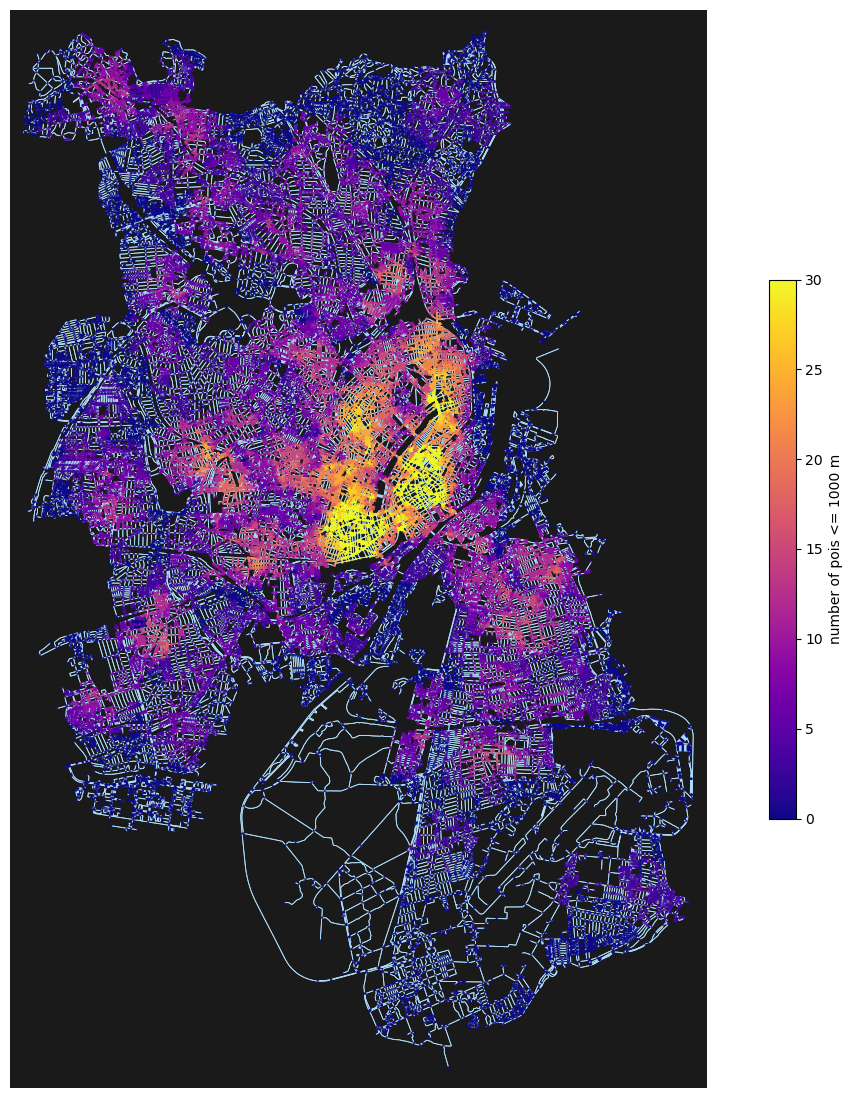

19.529347465239137


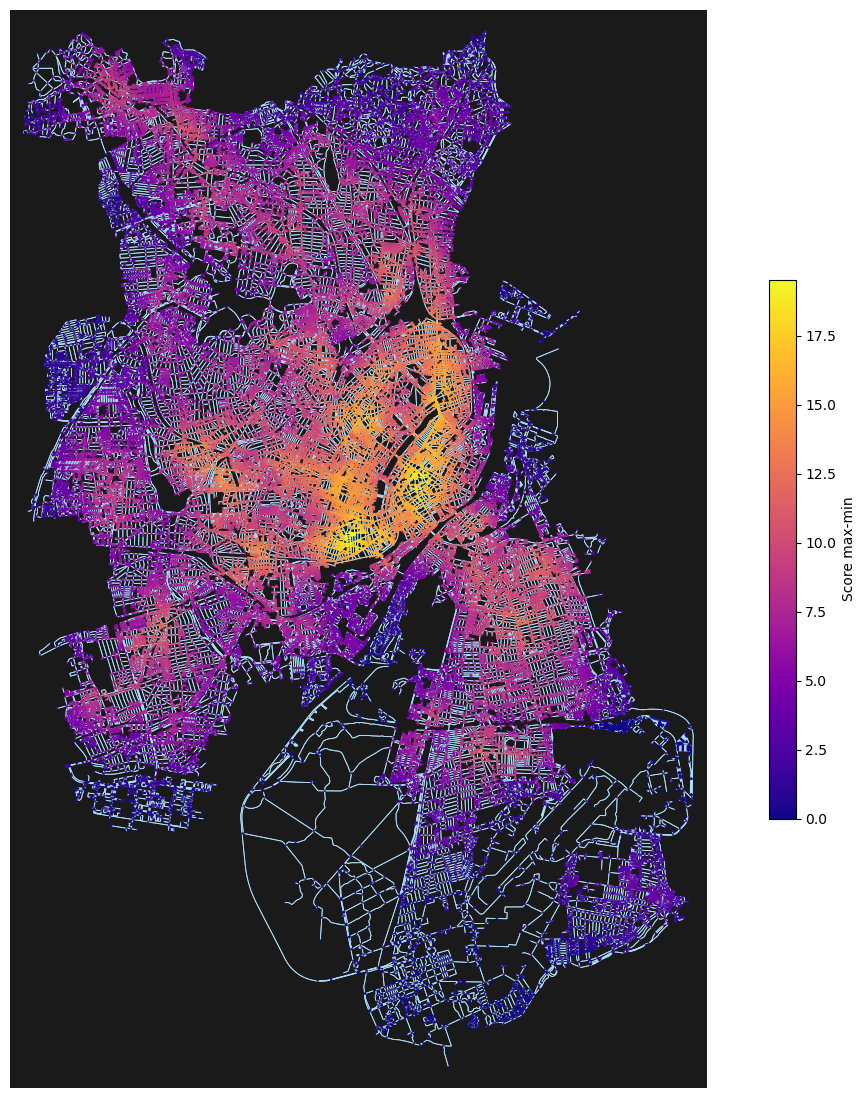

'\nfig, ax = ox.plot.plot_graph(\n    G,\n    node_size=0,\n    edge_color="#afdffe",\n    edge_linewidth=0.6,\n    bgcolor="#1a1a1a",\n    show=False,\n    close=False,\n    figsize=(16,14)\n)\n\n\nn_score.plot(\n    ax=ax,\n    column="pois",\n    cmap="plasma",\n    markersize=0.5,\n    alpha=0.8,\n    legend=True,\n    legend_kwds={\n        "shrink": 0.5,\n        "label": f"Score max-min",\n        "orientation": "vertical"\n    },\n    vmin=-vmax,\n    vmax=0\n)\n\nplt.show()'

In [9]:
"""
fig, axs = plt.subplots(1, 1, figsize=(10, 10))

ox.plot.plot_graph(
        G,
        ax = axs,
        node_size=0,
        edge_color="#afdffe",
        edge_linewidth=0.6,
        bgcolor="#1a1a1a",
        show=False,
        close=False
)

axs.set_title("accessibility_network")

def pls_draw_graph(G, n, dist, column, fig, axs):       
    vmin = n[column].min()
    vmax = n[column].max()
    
    n.plot(
        ax=axs,
        column=column,
        cmap="plasma",
        markersize=0.5,
        alpha=0.6,
        legend=True,
        legend_kwds={
            "shrink": 0.5,
            "label": f"Number of {column} ≤ {dist} m",
            "orientation": "vertical"
        },
        vmin=0,
        vmax=vmax
    )
    
    plt.tight_layout()
    plt.show()


pls_draw_graph(G, n, dist, "pois_education", fig, axs)
pls_draw_graph(G, n, dist, "pois_shops", fig, axs)
pls_draw_graph(G, n, dist, "pois_leisure", fig, axs)

pls_draw_graph(G, n, dist, "pois_healthcare", fig, axs)
pls_draw_graph(G, n, dist, "pois_transport", fig, axs)
"""

fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)

vmax = n["pois"].max()
print(vmax)

n.plot(
    ax=ax,
    column="pois",
    cmap="plasma",
    markersize=0.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"number of pois <= {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=vmax
)

plt.show()

vmax = n_score["pois"].max()
print(vmax)

fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)

n_score.plot(
    ax=ax,
    column="pois",
    cmap="plasma",
    markersize=0.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Score max-min",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=vmax
)

plt.show()

"""
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)


n_score.plot(
    ax=ax,
    column="pois",
    cmap="plasma",
    markersize=0.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Score max-min",
        "orientation": "vertical"
    },
    vmin=-vmax,
    vmax=0
)

plt.show()"""

In [7]:

net = network.nearest_pois(
            distance=1000,
            category="pois_education",
            num_pois=10,
        )


val = np.exp(net/500)
print(type(val))
print(val)

<class 'pandas.core.frame.DataFrame'>
                   1         2         3         4         5         6   \
osmid                                                                     
118738       2.254766  4.059005  5.389680  5.994797  7.389056  7.389056   
4924695592   2.202009  3.964033  5.263573  5.854531  7.389056  7.389056   
118744       3.854773  6.939321  7.389056  7.389056  7.389056  7.389056   
1277939659   3.979069  7.163079  7.389056  7.389056  7.389056  7.389056   
1277939654   3.432724  6.179553  7.389056  7.389056  7.389056  7.389056   
...               ...       ...       ...       ...       ...       ...   
13617451215  1.114266  3.692294  7.389056  7.389056  7.389056  7.389056   
13617451218  1.098415  3.724051  7.389056  7.389056  7.389056  7.389056   
13617451225  1.000000  4.090553  7.389056  7.389056  7.389056  7.389056   
13617451243  1.557014  5.159409  7.389056  7.389056  7.389056  7.389056   
13617451283  1.276526  4.229966  7.389056  7.389056  7.389056 